### 회귀 (Regression)
- 데이터가 평균과 같은 일정한 값으로 돌아가려는 경향을 이용한 통계학 기법이다.
- 여러 개의 독립 변수와 한 개의 종속 변수 간의 상관관계를 모델링하는 기법을 통칭한다.
- feature와 target 데이터 기반으로 학습하여 최적의 회귀 계수(W)를 찾는 것이 회귀의 목적이다.
- 아래는 복습 시간에 따른 다음 수업의 이해도를 수치로 표현한 표이다.


---
<div style="display: flex; justify-content: center; width: 900px;">
    <table style="margin-left: 20px; text-align: center; border: 1px solid #eee; width: 500px;">
        <tr>
            <th>복습 시간 (x)</th>
            <th>다음 수업의 이해도 (y)</th>
        </tr>
        <tr>
            <td>1</td>
            <td>2.2</td>
        </tr>
        <tr>
            <td>2</td>
            <td>5.8</td>
        </tr>
        <tr>
            <td>3</td>
            <td>7.6</td>
        </tr>
        <tr>
            <td>4</td>
            <td>9.3</td>
        </tr>
    </table>  
    <div style="margin-top: 60px;">
        <img src="./images/regression_train.png">
    </div>
</div>  

---

- 5시간 복습을 했을 때, 다음 수업의 이해도를 예측하고자 한다면,  
학습 데이터(x)를 가장 잘 표현할 수 있는 직선을 찾아야 하고, 이 식을 가설(Hypothesis)라고 한다.
- 아래는 위 데이터를 표현하고자 하는 직선의 방정식과 가설이다.

<img src="./images/regression_h.png" style="margin-left: 20px;">  

- 수학에서 W는 기울기, b는 절편이지만, 가설에서 W(Weight) 가중치, b(bias)를 편향이라 한다. 편향은 다양한 요인을 대표하는 값이다.

In [1]:
# %pip install torch torchvision

In [2]:
import torch

print(torch.__version__)

2.11.0+cpu


In [3]:
import numpy as np

print(torch.FloatTensor([1, 2, 3, 4]).shape)
print(torch.FloatTensor([[1, 2], [3, 4]]).shape)
print(torch.FloatTensor(np.arange(1, 5)).dim())
print(torch.FloatTensor([1, 2, 3, 4]).view(-1, 1))

torch.Size([4])
torch.Size([2, 2])
1
tensor([[1.],
        [2.],
        [3.],
        [4.]])


In [4]:
import numpy as np

X_train = torch.FloatTensor(np.array([1, 2, 3, 4])).view(-1, 1)
y_train = torch.FloatTensor(np.array([2.2, 5.8, 7.6, 9.3])).view(-1, 1)

print(X_train, y_train, sep='\n')

tensor([[1.],
        [2.],
        [3.],
        [4.]])
tensor([[2.2000],
        [5.8000],
        [7.6000],
        [9.3000]])


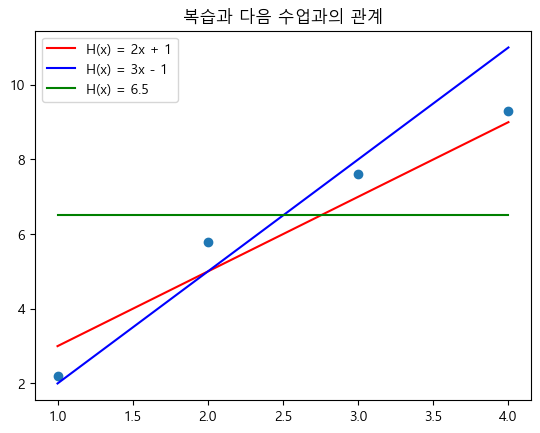

In [5]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.scatter(X_train, y_train)
plt.plot(X_train, 2 * X_train + 1, color='red', label="H(x) = 2x + 1")
plt.plot(X_train, 3 * X_train - 1, color='blue', label="H(x) = 3x - 1")
plt.plot(X_train, 0 * X_train + 6.5, color='green', label="H(x) = 6.5")
plt.title("복습과 다음 수업과의 관계")
plt.legend()
plt.show()

- 위 3개의 직선 중에서 데이터를 가장 잘 표현한 직선을 고르고자 한다면, 오차(error)를 구해봐야 한다.

<table style="margin-left: 20px; text-align: center; border: 1px solid red; width: 700px; margin-bottom: 50px;">
    <caption style="font-weight: bold">H(x) = 2x + 1</caption>
    <tr>
        <th>X</th>
        <th>1</th>
        <th>2</th>
        <th>3</th>
        <th>4</th>
    </tr>
    <tr>
        <td>Y</td>
        <td>2.2</td>
        <td>5.8</td>
        <td>7.6</td>
        <td>9.3</td>
    </tr>
    <tr>
        <td>H(x)</td>
        <td>3</td>
        <td>5</td>
        <td>7</td>
        <td>9</td>
    </tr>
    <tr style="font-weight: bold">
        <td>E</td>
        <td>-0.8</td>
        <td>0.8</td>
        <td>0.6</td>
        <td>0.3</td>
    </tr>
</table>

<table style="margin-left: 20px; text-align: center; border: 1px solid blue; width: 700px; margin-bottom: 50px;">
    <caption style="font-weight: bold">H(x) = 3x - 1</caption>
    <tr>
        <th>X</th>
        <th>1</th>
        <th>2</th>
        <th>3</th>
        <th>4</th>
    </tr>
    <tr>
        <td>Y</td>
        <td>2.2</td>
        <td>5.8</td>
        <td>7.6</td>
        <td>9.3</td>
    </tr>
    <tr>
        <td>H(x)</td>
        <td>2</td>
        <td>5</td>
        <td>8</td>
        <td>11</td>
    </tr>
    <tr style="font-weight: bold">
        <td>E</td>
        <td>0.2</td>
        <td>0.8</td>
        <td>-0.4</td>
        <td>-1.7</td>
    </tr>
</table>

<table style="margin-left: 20px; text-align: center; border: 1px solid green; width: 700px;">
    <caption style="font-weight: bold">H(x) = 6.5</caption>
    <tr>
        <th>X</th>
        <th>1</th>
        <th>2</th>
        <th>3</th>
        <th>4</th>
    </tr>
    <tr>
        <td>Y</td>
        <td>2.2</td>
        <td>5.8</td>
        <td>7.6</td>
        <td>9.3</td>
    </tr>
    <tr>
        <td>H(x)</td>
        <td>6.5</td>
        <td>6.5</td>
        <td>6.5</td>
        <td>6.5</td>
    </tr>
    <tr style="font-weight: bold">
        <td>E</td>
        <td>-4.3</td>
        <td>-0.7</td>
        <td>1.1</td>
        <td>2.8</td>
    </tr>
</table>

---  

- E = Y - H(x)로 계산하면 E가 음수로 나올 수 있기 때문에 전체 오차의 크기를 측정할 수 없다.
- 따라서 **각 제곱을 한 뒤 더하고 평균**을 구한다.
- 이를 **"평균 제곱 오차(MSE)"** 라고 한다.

<img src="./images/regression_e.png" style="margin-left: 20px;">

- 이 때, 오차를 구해주는 함수로 표현하면 아래와 같이 손실 함수(loss function)로 표현된다.

<img src="./images/regression_loss_function01.png" style="margin-left: 20px;">  

- 즉, 손실 함수가 최소가 되는 W와 b를 구함으로써 훈련 데이터를 가장 잘 나타내는 직선을 고를 수 있다.

<img src="./images/regression_loss_function02.png" style="margin-left: 20px;">  

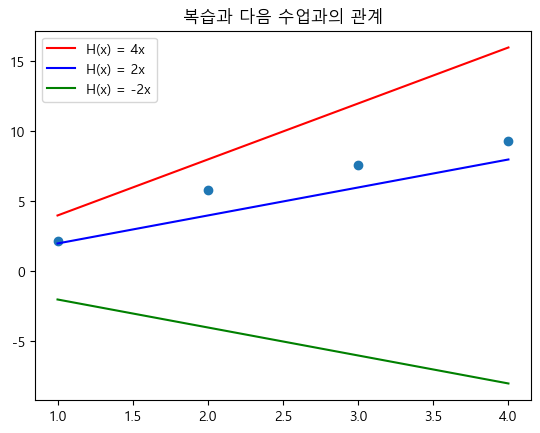

In [6]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.scatter(X_train, y_train)
plt.plot(X_train, 4 * X_train, color='red', label="H(x) = 4x")
plt.plot(X_train, 2 * X_train, color='blue', label="H(x) = 2x")
plt.plot(X_train, -2 * X_train, color='green', label="H(x) = -2x")
plt.title("복습과 다음 수업과의 관계")
plt.legend()
plt.show()

- 따라서 기울기와 오차는 기울기가 커질수록 Loss 값도 커지고,  
지나치게 작아져도 Loss 값은 계속 커지기 때문에 아래와 같은 관계 그래프가 나온다.

<img src="./images/gradient_descent01.png" style="margin-left: 20px;">  

- 위 그래프에서 Loss 값이 가장 최소가 되는 W를 찾아야 한다.
- 임의의 초기값 W를 정한 뒤, 점차 W를 수정해야 하는데, 이를 경사 하강법(Gradient Descent)으로 진행할 수 있다.

<img src="./images/gradient_descent02.png" style="margin-left: 20px;">  

- W가 아래로 내려갈 수록 접선의 기울기가 점점 작아지고 Loss 값이 최소값이 되는 부분은 결국 접선의 기울기가 0으로 된다.
- 이 말은 즉, Loss 값이 최소가 되는 지점은 미분값이 0이 되는 지점이다.
- 기존 W에 경사 하강법 알고리즘에 대한 값을 빼주면서 점점 업데이트되며, 이는 아래 수식으로 표현이 가능하다.  

<img src="./images/gradient_descent03.png" style="margin-left: 20px;">  

- 빼줄 값에 η(에타)를 곱해줄 수 있는데, 이 η(에타)가 바로 학습률이다.
- 학습률로 하강 속도를 조절할 수 있으며, 너무 크게 주면 발산하고 너무 작게 주면 최소값까지 도달하지 못할 수 있다.  

<img src="./images/learning_rate.png" style="margin-left: -70px;">  

In [7]:
import numpy as np

X_train = torch.FloatTensor(np.array([1, 2, 3, 4])).view(-1, 1)
y_train = torch.FloatTensor(np.array([2.2, 5.8, 7.6, 9.3])).view(-1, 1)

print(X_train.shape, y_train.shape, sep='\n')

torch.Size([4, 1])
torch.Size([4, 1])


In [8]:
W = torch.zeros(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)


print(W, b)

tensor([0.], requires_grad=True) tensor([0.], requires_grad=True)


In [9]:
H = W * X_train + b
print(H.shape)

torch.Size([4, 1])


In [10]:
loss = torch.mean((y_train - H) ** 2)

print(loss)

tensor(45.6825, grad_fn=<MeanBackward0>)


In [11]:
import torch
from torch.optim import SGD

torch.manual_seed(124)

X_train = torch.FloatTensor(np.array([1, 2, 3, 4])).view(-1, 1)
y_train = torch.FloatTensor(np.array([2.2, 5.8, 7.6, 9.3])).view(-1, 1)

W = torch.zeros(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

optimizer = SGD([W, b], lr=0.01)

epochs = 1200

for epoch in range(1, epochs + 1):
    H = W * X_train + b
    loss = torch.mean((y_train - H) ** 2)
    # 다음 기울기 계산을 위해 기존 기울기 초기화
    optimizer.zero_grad()

    # 손실 함수 미분 후 기울기 계산
    loss.backward()

    # W, b 업데이트
    optimizer.step()

    if epoch % 100 == 0:
        print(f'{epoch}/{epochs}: W: {W.item():.4f}, b: {b.item():.4f}, loss: {loss.item():.4f}')

100/1200: W: 2.2342, b: 0.6729, loss: 0.2701
200/1200: W: 2.2538, b: 0.6152, loss: 0.2663
300/1200: W: 2.2684, b: 0.5724, loss: 0.2643
400/1200: W: 2.2792, b: 0.5407, loss: 0.2631
500/1200: W: 2.2871, b: 0.5172, loss: 0.2625
600/1200: W: 2.2931, b: 0.4998, loss: 0.2622
700/1200: W: 2.2975, b: 0.4869, loss: 0.2620
800/1200: W: 2.3007, b: 0.4773, loss: 0.2619
900/1200: W: 2.3031, b: 0.4703, loss: 0.2618
1000/1200: W: 2.3049, b: 0.4650, loss: 0.2618
1100/1200: W: 2.3062, b: 0.4611, loss: 0.2618
1200/1200: W: 2.3072, b: 0.4582, loss: 0.2618


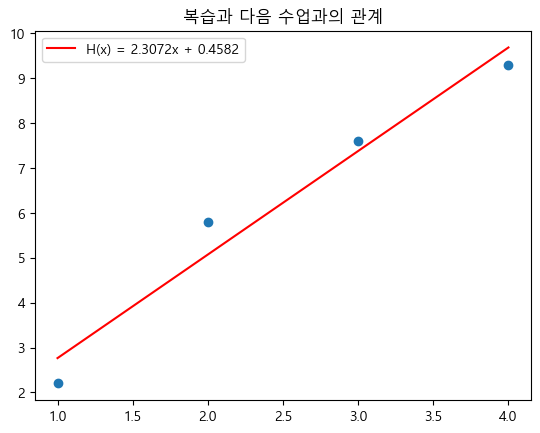

In [12]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.scatter(X_train, y_train)
plt.plot(X_train, 2.3072 * X_train + 0.4582, color='red', label="H(x) = 2.3072x + 0.4582")
plt.title("복습과 다음 수업과의 관계")
plt.legend()
plt.show()

In [14]:
from torch.nn import Module, Linear

class LinearRegressionModel(Module):
    def __init__(self):
        super().__init__()
        self.linear = Linear(1, 1)

    def forward(self, x):
        return self.linear(x)


In [16]:
import torch
from torch.nn import Linear
from torch.nn.functional import mse_loss
from torch.optim import SGD

torch.manual_seed(124)

X_train = torch.FloatTensor(np.array([1, 2, 3, 4])).view(-1, 1)
y_train = torch.FloatTensor(np.array([2.2, 5.8, 7.6, 9.3])).view(-1, 1)

l_r = LinearRegressionModel()

optimizer = SGD(l_r.parameters(), lr=0.01)

epochs = 1200

for epoch in range(1, epochs + 1):
    H = l_r(X_train)
    loss = mse_loss(H, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        W = list(l_r.parameters())[0].item()
        b = list(l_r.parameters())[1].item()

        print(f'{epoch}/{epochs}: W: {W:.4f}, b: {b:.4f}, loss: {loss.item():.4f}')

100/1200: W: 2.1216, b: 1.0041, loss: 0.3133
200/1200: W: 2.1704, b: 0.8605, loss: 0.2901
300/1200: W: 2.2065, b: 0.7542, loss: 0.2773
400/1200: W: 2.2333, b: 0.6754, loss: 0.2703
500/1200: W: 2.2532, b: 0.6170, loss: 0.2664
600/1200: W: 2.2679, b: 0.5737, loss: 0.2643
700/1200: W: 2.2788, b: 0.5417, loss: 0.2632
800/1200: W: 2.2869, b: 0.5179, loss: 0.2625
900/1200: W: 2.2929, b: 0.5003, loss: 0.2622
1000/1200: W: 2.2973, b: 0.4873, loss: 0.2620
1100/1200: W: 2.3006, b: 0.4776, loss: 0.2619
1200/1200: W: 2.3030, b: 0.4705, loss: 0.2618


In [17]:
import pandas as pd

test_df = pd.DataFrame({'x': [1, 2, 3, 4], 'y': [2.2, 5.8, 7.6, 9.3]})
test_df

,x,y
0,1,2.2
1,2,5.8
2,3,7.6
3,4,9.3


In [ ]:
from torch.nn import Module, Linear

class LinearRegressionModel(Module):
    def __init__(self):
        super().__init__()
        self.linear = Linear(1, 1)

    def forward(self, x):
        return self.linear(x)


In [18]:
import torch
from torch.nn import Linear
from torch.nn.functional import mse_loss
from torch.optim import SGD

torch.manual_seed(124)

feature, target = test_df.x, test_df.y

X_train = torch.FloatTensor(feature.values).view(-1, 1)
y_train = torch.FloatTensor(target.values).view(-1, 1)

l_r = LinearRegressionModel()

optimizer = SGD(l_r.parameters(), lr=0.01)

epochs = 1200

for epoch in range(1, epochs + 1):
    H = l_r(X_train)
    loss = mse_loss(H, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        W = list(l_r.parameters())[0].item()
        b = list(l_r.parameters())[1].item()

        print(f'{epoch}/{epochs}: W: {W:.4f}, b: {b:.4f}, loss: {loss.item():.4f}')

100/1200: W: 2.1216, b: 1.0041, loss: 0.3133
200/1200: W: 2.1704, b: 0.8605, loss: 0.2901
300/1200: W: 2.2065, b: 0.7542, loss: 0.2773
400/1200: W: 2.2333, b: 0.6754, loss: 0.2703
500/1200: W: 2.2532, b: 0.6170, loss: 0.2664
600/1200: W: 2.2679, b: 0.5737, loss: 0.2643
700/1200: W: 2.2788, b: 0.5417, loss: 0.2632
800/1200: W: 2.2869, b: 0.5179, loss: 0.2625
900/1200: W: 2.2929, b: 0.5003, loss: 0.2622
1000/1200: W: 2.2973, b: 0.4873, loss: 0.2620
1100/1200: W: 2.3006, b: 0.4776, loss: 0.2619
1200/1200: W: 2.3030, b: 0.4705, loss: 0.2618


In [19]:
# 연봉에 따른 자동차 구매 가격 회귀 모델 제작
import pandas as pd

c_df = pd.read_csv('./datasets/car_purchasing.csv')
c_df

,Customer Name,Customer e-mail,Country,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,USA,0,42,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,USA,0,41,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,USA,1,43,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,USA,1,58,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,USA,1,57,59729.15130,5358.712177,560304.0671,55915.46248
...,...,...,...,...,...,...,...,...,...
495,Walter,ligula@Cumsociis.ca,USA,0,41,71942.40291,6995.902524,541670.1016,48901.44342
496,Vanna,Cum.sociis.natoque@Sedmolestie.edu,USA,1,38,56039.49793,12301.456790,360419.0988,31491.41457
497,Pearl,penatibus.et@massanonante.com,USA,1,54,68888.77805,10611.606860,764531.3203,64147.28888
498,Nell,Quisque.varius@arcuVivamussit.net,USA,1,59,49811.99062,14013.034510,337826.6382,45442.15353


In [20]:
c_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer Name        500 non-null    object 
 1   Customer e-mail      500 non-null    object 
 2   Country              500 non-null    object 
 3   Gender               500 non-null    int64  
 4   Age                  500 non-null    int64  
 5   Annual Salary        500 non-null    float64
 6   Credit Card Debt     500 non-null    float64
 7   Net Worth            500 non-null    float64
 8   Car Purchase Amount  500 non-null    float64
dtypes: float64(4), int64(2), object(3)
memory usage: 35.3+ KB


In [21]:
c_df.columns

Index(['Customer Name', 'Customer e-mail', 'Country', 'Gender', 'Age',
       'Annual Salary', 'Credit Card Debt', 'Net Worth',
       'Car Purchase Amount'],
      dtype='object')

In [22]:
columns = ['Gender', 'Age', 'Annual Salary', 'Credit Card Debt', 'Net Worth', 'Car Purchase Amount']
pre_c_df = c_df[columns]
pre_c_df

,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
0,0,42,62812.09301,11609.380910,238961.2505,35321.45877
1,0,41,66646.89292,9572.957136,530973.9078,45115.52566
2,1,43,53798.55112,11160.355060,638467.1773,42925.70921
3,1,58,79370.03798,14426.164850,548599.0524,67422.36313
4,1,57,59729.15130,5358.712177,560304.0671,55915.46248
...,...,...,...,...,...,...
495,0,41,71942.40291,6995.902524,541670.1016,48901.44342
496,1,38,56039.49793,12301.456790,360419.0988,31491.41457
497,1,54,68888.77805,10611.606860,764531.3203,64147.28888
498,1,59,49811.99062,14013.034510,337826.6382,45442.15353


In [26]:
pre_c_df.corr()['Car Purchase Amount'].sort_values(ascending=False)[1:]

Age                 0.633273
Annual Salary       0.617862
Net Worth           0.488580
Credit Card Debt    0.028882
Gender             -0.066408
Name: Car Purchase Amount, dtype: float64

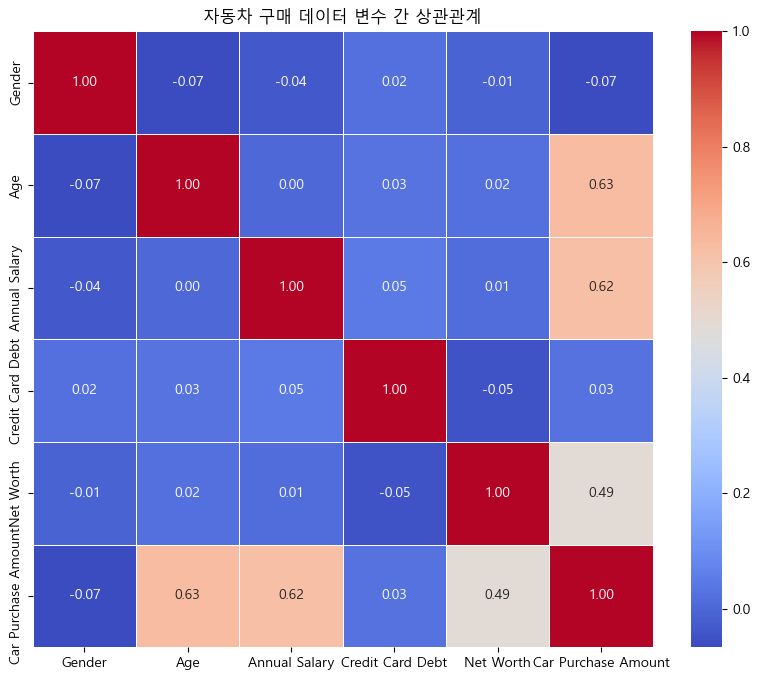

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

corr = pre_c_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("자동차 구매 데이터 변수 간 상관관계")
plt.show()

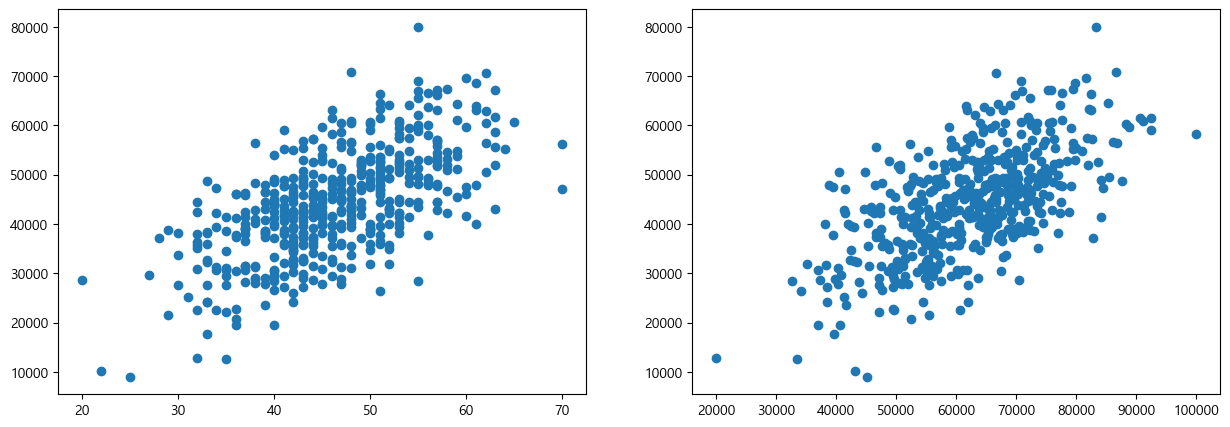

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(pre_c_df['Age'], pre_c_df['Car Purchase Amount'])
axes[1].scatter(pre_c_df['Annual Salary'], pre_c_df['Car Purchase Amount'])
plt.show()

In [29]:
pre_c_df = pre_c_df[['Annual Salary', 'Car Purchase Amount']]
pre_c_df

,Annual Salary,Car Purchase Amount
0,62812.09301,35321.45877
1,66646.89292,45115.52566
2,53798.55112,42925.70921
3,79370.03798,67422.36313
4,59729.15130,55915.46248
...,...,...
495,71942.40291,48901.44342
496,56039.49793,31491.41457
497,68888.77805,64147.28888
498,49811.99062,45442.15353


array([[<Axes: title={'center': 'Annual Salary'}>,
        <Axes: title={'center': 'Car Purchase Amount'}>]], dtype=object)

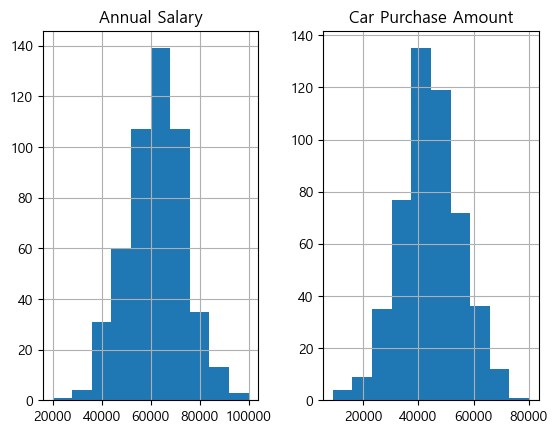

In [30]:
pre_c_df.hist()

In [31]:
from sklearn.preprocessing import StandardScaler

scale_c_df = pre_c_df.copy()

scaler = StandardScaler()
std_annual_salary = scaler.fit_transform(pre_c_df[['Annual Salary']])
scale_c_df['Annual Salary'] = std_annual_salary

condition1 = scale_c_df['Annual Salary'] >= -3
condition2 = scale_c_df['Annual Salary'] <= 3
condition = condition1 & condition2

scale_c_df = scale_c_df.iloc[scale_c_df[condition].index]
scale_c_df

,Annual Salary,Car Purchase Amount
0,0.058576,35321.45877
1,0.386570,45115.52566
2,-0.712361,42925.70921
3,1.474794,67422.36313
4,-0.205111,55915.46248
...,...,...
495,0.839501,48901.44342
496,-0.520691,31491.41457
497,0.578321,64147.28888
498,-1.053335,45442.15353


In [34]:
pre_c_df.iloc[scale_c_df.index].reset_index(drop=True, inplace=True)

In [36]:
from torch.nn import Module, Linear

class LinearRegressionModel(Module):
    def __init__(self):
        super().__init__()
        self.linear = Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

In [45]:
from sklearn.model_selection import train_test_split
import torch
from torch.nn.functional import mse_loss
from torch.optim import SGD

torch.manual_seed(124)

feature, target = pre_c_df.iloc[:, :-1], pre_c_df.iloc[:, -1]

X_train, X_test, y_train, y_test = \
train_test_split(feature, target, test_size=0.2, random_state=124)

X_train = torch.FloatTensor(X_train.values).view(-1, 1)
y_train = torch.FloatTensor(y_train.values).view(-1, 1)

X_test = torch.FloatTensor(X_test.values).view(-1, 1)
y_test = torch.FloatTensor(y_test.values).view(-1, 1)

l_r = LinearRegressionModel()

optimizer = SGD(l_r.parameters(), lr=1e-11)

epochs = 1700

for epoch in range(1, epochs + 1):
    H = l_r(X_train)
    loss = mse_loss(H, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        W = list(l_r.parameters())[0].item()
        b = list(l_r.parameters())[1].item()

        print(f'{epoch}/{epochs}: W: {W:.4f}, b: {b:.4f}, loss: {loss.item():.4f}')

100/1700: W: 0.7065, b: 0.2623, loss: 73355408.0000
200/1700: W: 0.7069, b: 0.2623, loss: 73354904.0000
300/1700: W: 0.7069, b: 0.2623, loss: 73354904.0000
400/1700: W: 0.7069, b: 0.2623, loss: 73354904.0000
500/1700: W: 0.7069, b: 0.2623, loss: 73354904.0000
600/1700: W: 0.7069, b: 0.2623, loss: 73354904.0000
700/1700: W: 0.7069, b: 0.2623, loss: 73354904.0000
800/1700: W: 0.7069, b: 0.2623, loss: 73354904.0000
900/1700: W: 0.7069, b: 0.2623, loss: 73354904.0000
1000/1700: W: 0.7069, b: 0.2623, loss: 73354904.0000
1100/1700: W: 0.7069, b: 0.2623, loss: 73354904.0000
1200/1700: W: 0.7069, b: 0.2623, loss: 73354904.0000
1300/1700: W: 0.7069, b: 0.2623, loss: 73354904.0000
1400/1700: W: 0.7069, b: 0.2623, loss: 73354904.0000
1500/1700: W: 0.7069, b: 0.2623, loss: 73354904.0000
1600/1700: W: 0.7069, b: 0.2623, loss: 73354904.0000
1700/1700: W: 0.7069, b: 0.2623, loss: 73354904.0000


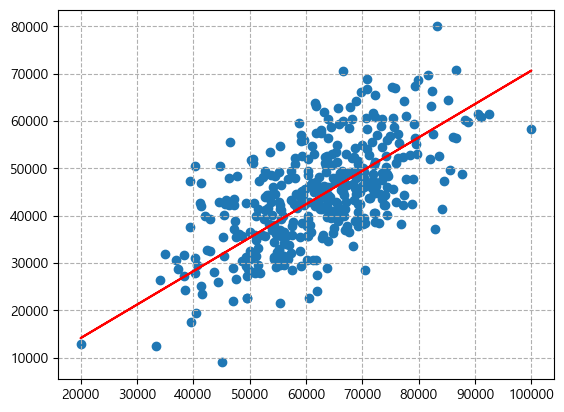

In [46]:
import matplotlib.pylab as plt

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.scatter(X_train, y_train)
plt.plot(X_train, 0.7069 * X_train + 0.2623, color='red')
plt.grid(visible=True, linestyle='--')
plt.show()

In [59]:
H = 0.7069 * X_train + 0.2623

# RMSE
print(np.sqrt(mse_loss(H, y_train).item()))

8564.748215797123


In [60]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

feature, target = pre_c_df.iloc[:, :-1], pre_c_df.iloc[:, -1]

X_train, X_test, y_train, y_test = \
train_test_split(feature, target, test_size=0.2, random_state=124)

l_r = LinearRegression()
l_r.fit(X_train, y_train)
print(f'W: {l_r.coef_[0]}, b: {l_r.intercept_}')

W: 0.580146553797051, b: 8166.491552180072


In [61]:
from sklearn.metrics import mean_squared_error

prediction = l_r.predict(X_test)
print(f'MSE loss: {mean_squared_error(y_test, prediction)}, \
RMSE loss: {np.sqrt(mean_squared_error(y_test, prediction))}')

MSE loss: 73836562.95967925, RMSE loss: 8592.820431015607


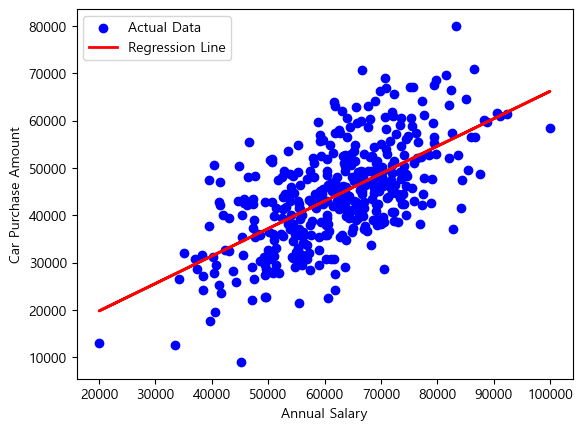

In [63]:
import matplotlib.pyplot as plt

plt.scatter(X_train, y_train, color='blue', label='Actual Data')
plt.plot(X_train, l_r.predict(X_train), color='red', linewidth=2, label="Regression Line")

plt.xlabel("Annual Salary")
plt.ylabel("Car Purchase Amount")
plt.legend()
plt.show()

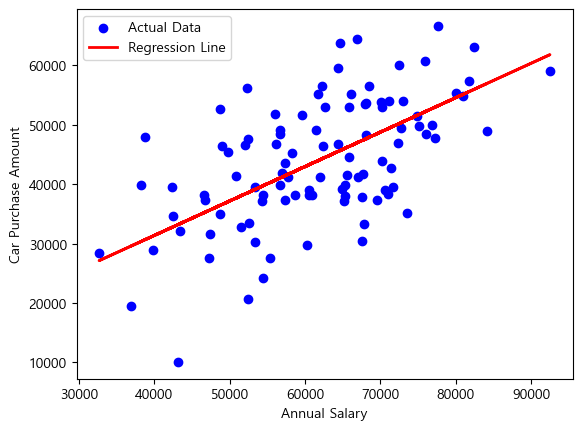

In [64]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, l_r.predict(X_test), color='red', linewidth=2, label="Regression Line")

plt.xlabel("Annual Salary")
plt.ylabel("Car Purchase Amount")
plt.legend()
plt.show()

In [65]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error

def get_evaluation(y_test, prediction):
    MAE =  mean_absolute_error(y_test, prediction)
    MSE = mean_squared_error(y_test, prediction)
    RMSE = np.sqrt(MSE)
    MSLE = mean_squared_log_error(y_test, prediction)
    RMSLE = np.sqrt(mean_squared_log_error(y_test, prediction))
    R2 = r2_score(y_test, prediction)

    print('MAE: {:.4f}, MSE: {:.4f}, RMSE: {:.4f}, MSLE: {:.4f}, RMSLE: {:.4f}, R2: {:.4f}'.format(MAE, MSE, RMSE, MSLE, RMSLE, R2))

In [66]:
# MAE
# 예측값과 실제값 사이의 평균 차이를 직관적으로 확인할 수 있다.

# MSE
# 모델을 학습시킬 때 루트가 씌워진 RMSE보다 
# 제곱 형태인 MSE가 미분하기 훨씬 깔끔하여 컴퓨터가 계산하기 좋다.
# 오차를 제곱하면 큰 오차는 훨씬 더 크게 증폭되기 때문에,
# 모델이 이상치에 대해 더 강하게 인지할 수 있다.
# 따라서 회귀 모델은 기본 손실 함수가 MSE이다.

# RMSE
# 타겟 데이터의 단위와 같기 때문에 사람이 인식하고 판단하기 좋다.
# 수학적으로 항상 RMSE ≥ MAE 성립

# RMSE - MAE 값이 크다면(차이가 클 때)
# - 모델이 대부분은 잘 맞추더라도, 몇몇 데이터에서 아주 크게 틀리고 있다
# - 타겟값이나 편향이 심한 피처에 로그를 취해 수치 범위를 압축(이상치의 영향력을 최소화)

# RMSE - MAE 값이 0에 가깝다면(차이가 작을 때)
# - 모든 데이터에서 오차가 비교적 일정하게 발생하고 있다.
# - 모델의 표현력 자체가 부족하거나 중요한 정보 누락.
# - Feature Engineering(새로운 변수를 생성하거나 외부 데이터 추가)
# - 비선형 모델로 전환
# - MinMaxScaler를 통해 모든 피처를 동일한 단위로 설정

# MSLE
# - MSE에 Log를 취해 큰 단위의 수치를 압축하여 보여준다.
# - 사람이 직관적으로 이해하기 어려운 수치이다.

# RMSLE
# - 수치가 아닌 오차의 비율을 나타내며, 0.2336일 경우 약 23%의 오차가 발생한다는 뜻이다.
get_evaluation(y_test, prediction)

MAE: 6964.9823, MSE: 73836562.9597, RMSE: 8592.8204, MSLE: 0.0546, RMSLE: 0.2336, R2: 0.3302


$$R^2 = 1 - \frac{\sum (Actual - Predict)^2}{\sum (Actual - Mean)^2} = 1 - \frac{MSE}{Var(Y)}$$분모 ($\sum (Actual - Mean)^2$): 평균만 알 때 발생하는 오차  
분자 ($\sum (Actual - Predict)^2$): 학습 후에 발생한 오차(Error)  

R2
- 전체 변동성(100) 중에 모델이 해결하지 못한 오차의 비율을 뺀 값
- 내 모델이 평균이라는 기준점보다 얼마나 더 똑똑해졌는지를 나타내는 척도